---
title: Assignment - 5
author: Siddharth Rajesh
date: 26-03-2026
---

## Importing our libraries

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

## Function to load the network from the tab-seperated file (some of the rows are not properly tab-spaced)

In [2]:
def create_network(file_path):
    G = nx.Graph()          # Create the graph object
    with open(file_path, 'r') as f:     # load the file
        next(f)                 # Skip header
        for line in f:
            parts = line.strip().split()    # Remove whitespace and split based on the tab
            if len(parts) == 2:
                G.add_edge(parts[0], parts[1])      # Adding the edges to the graph
    return G                                # Returning the graph

### Function to calculate some of the basic network statistics (No of Nodes/Edges, Average Clustering Coefficient)

In [3]:
def network_stats(G: nx.Graph):
    print('Calculating Network Metrics...')
    metrics = {
        'n_nodes': G.number_of_nodes(),     # Calculates the number of nodes
        'n_edges': G.number_of_edges(),     # Calculates the number of edges
        "clustering_coefficients": nx.clustering(G),    # Calculates the clustering coefficient of all the proteins
        'avg_clustering_coeff': nx.average_clustering(G),   # Calculates the average clustering coefficient of the network
        'avg_degree': G.number_of_edges() / G.number_of_nodes() # Calculates the average degree of the network
    }
    degrees = {node: deg for node, deg in G.degree if node!="-" and node.strip()!=""}       # Stores the degrees of each node in the network
    return metrics, degrees     # Return the metrics and the degrees

### Function to plot the degree distribution of the network in both normal scale and in log scale

In [4]:
def plot_degree_distribution(degrees):
    degree_values = list(degrees.values())      # Extract the degrees and store as a list
    unique_degrees, counts = np.unique(degree_values, return_counts=True)   # Get the unique degrees and the count for each degree
    
    fig, axes = plt.subplots(1, 2, figsize = (16, 8))
    
    # Log-log plot for degree distribution
    axes[0].loglog(unique_degrees, counts, 'bo-', alpha=0.6, markersize=0.4)        
    axes[0].set_xlabel('Log Degree: k')
    axes[0].set_ylabel('Log Degree Distribution: p(k)')
    axes[0].set_title('Log Degree Distribution Graph')
    
    # Scatter plot for degree distribution
    axes[1].scatter(unique_degrees, counts,c='r', alpha=0.6, s=30)
    axes[1].set_xlabel('Degree k')
    axes[1].set_ylabel('Degree Distribution p(k)')
    axes[1].set_title('Degree Distribution')
    plt.tight_layout()
    plt.savefig('results/degree_distribution.png')
    plt.show()
    plt.close()

## Run the functions to get the degree distribution

Calculating Network Metrics...
Number of Nodes: 14666
Number of Edges in the Protein-Protein Interaction network: 70658
Clustering Coefficient of every in the network:              Protein  Clustering_coefficient
0      1810055G02Rik                0.000000
1              MPRIP                0.133333
2              RAI14                0.123810
3               TPM1                0.102564
4      2810046L04Rik                0.000000
...              ...                     ...
14661         SETDB2                0.000000
14662           tor2                0.000000
14663       twist1-A                0.000000
14664          ube2i                0.000000
14665        zbtb16a                0.000000

[14666 rows x 2 columns]
Average Clustering Coefficient of the entire network: 0.210
Average degree of nodes in the network: 4.818



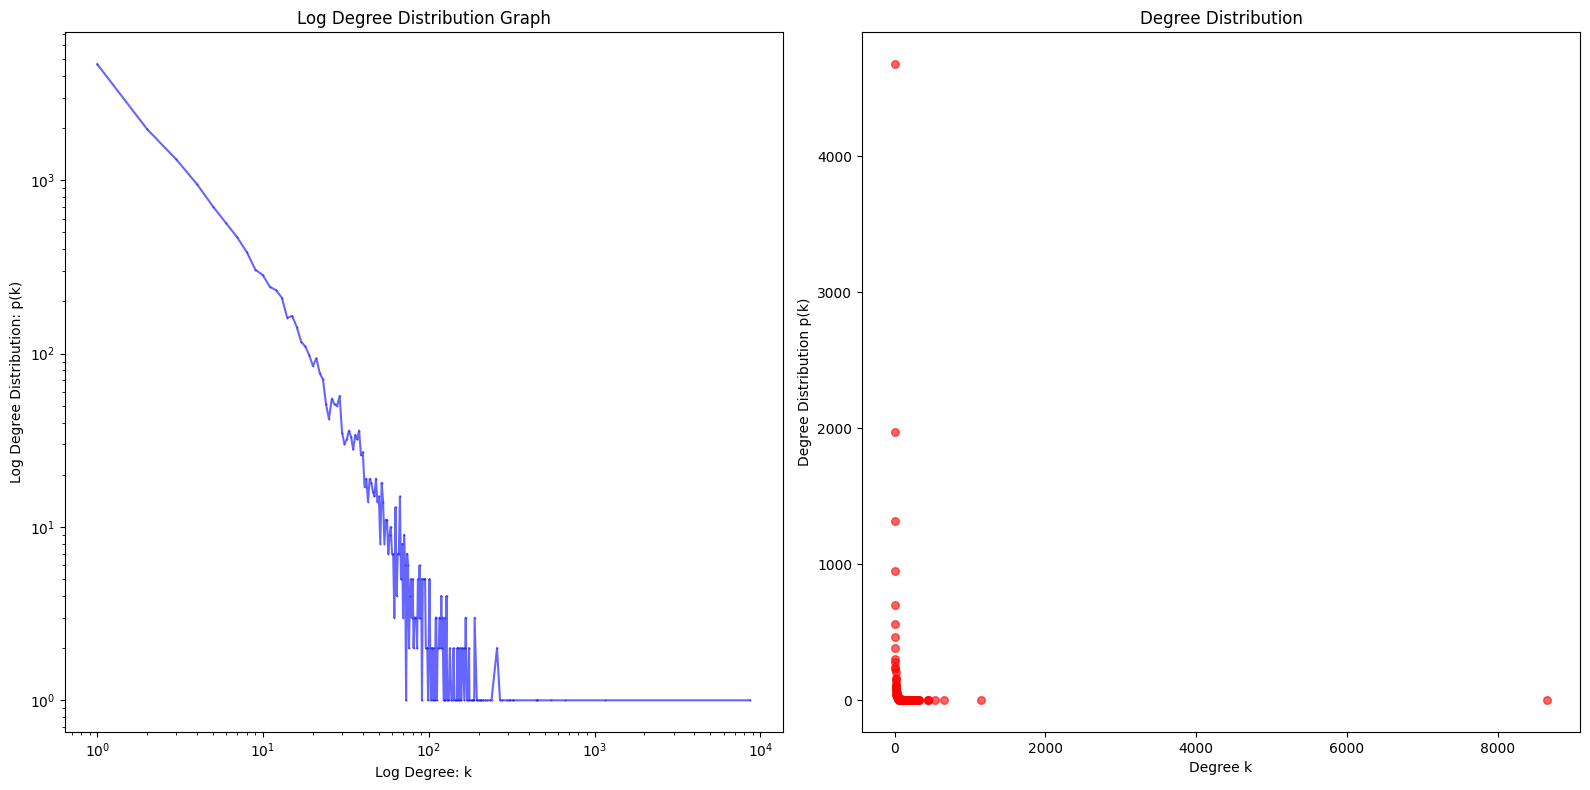

In [ ]:
G = create_network('data/Human-PPI.txt')
metrics, degree = network_stats(G)
cc_df = pd.DataFrame(metrics['clustering_coefficients'].items(), columns=['Protein', 'Clustering_coefficient'])
print(
    f"Number of Nodes: {metrics['n_nodes']}\n"
    f"Number of Edges in the Protein-Protein Interaction network: {metrics['n_edges']}\n"
    f"Clustering Coefficient of every in the network:\n {cc_df}\n"
    f"Average Clustering Coefficient of the entire network: {metrics['avg_clustering_coeff']:.3f}\n"
    f"Average degree of nodes in the network: {metrics['avg_degree']:.3f}\n"
)

plot_degree_distribution(degree)


## Function to load the protein list from the txt file

In [6]:
def load_protein_list(file_path):
    with open(file_path, 'r') as f:
        protein_list = []       # Initiate the list
        for line in f:
            line = line.strip() # Remove whitespace
            protein_list.append(line)   # Append each protein in the file
    return protein_list

### Function to calculate the shortest path length between every pair of proteins in the txt file using the created network

In [7]:
def calculate_shortest_path_lengths(G: nx.Graph, list: list):
    path_lengths = []       # Initiate the list to store the path lengths
    for i in range(len(list)):  # Index the full length of the list
        for j in range(i+1, len(list)):     # Index the next pair required to calculate the path length
            if list[i] in G and list[j] in G:   # Ensuring that the proteins are in the graph
                try:
                    shortest_path_length = nx.shortest_path_length(G, source=list[i], target=list[j])   # Calculate the shortest path length between the protein pairs from the provided list
                    path_lengths.append((list[i], list[j], shortest_path_length))       # Append (protein_1, protein_2, shortest_path_length)
                except nx.NetworkXNoPath:
                    continue    
            else:
                continue
    return path_lengths

### Function to compare the calculated path lengths between the 2 protein lists

In [8]:
def compare_path_lengths(list1: list, list2: list):
    list1_path_lengths = [path_length for _, _, path_length in list1]       # Extract the path lengths alone from both the lists
    list2_path_lengths = [path_length for _, _, path_length in list2]
    stat, pvalue = mannwhitneyu(list1_path_lengths, list2_path_lengths, alternative='two-sided')    # non-parametric test to compare distribution of samples
    print(
        f"Mann-Whitney U Statistic for Difference between samples from the same distribution: {stat:.3f}\n"
        f"P-value: {pvalue:.4f}"
    )
    if pvalue < 0.05:
        print(f"Both the samples have different distribution of path lengths")
    else:
        print(f"Both the samples have the same distribution of path lengths")
    
    # Histogram to compare the Path lengths obtained from both the lists.
    plt.hist(list1_path_lengths, alpha = 0.5, label = 'Protein List 1')
    plt.hist(list2_path_lengths, alpha = 0.5, label = 'Protein List 2')
    plt.xlabel('Path Length')
    plt.ylabel("Frequency of path length")
    plt.title("Comparison of path lengths between the 2 protein lists")
    plt.tight_layout()
    plt.savefig('results/path_length_comparison.png')
    plt.show()
    plt.close()

### Run the functions to load the protein list and print the calculated path lengths

In [9]:
list1 = load_protein_list('data/protein-list1.txt')
list1_path_lengths = calculate_shortest_path_lengths(G, list1)
for source, target, path_length in list1_path_lengths:
    print(
        f"Path Length between {source} and {target}: {path_length}"
    )

Path Length between LAS1L and FKBP4: 2
Path Length between LAS1L and RBM6: 2
Path Length between LAS1L and UPF1: 2
Path Length between LAS1L and SLC25A5: 2
Path Length between LAS1L and DHX33: 2
Path Length between LAS1L and ELAC2: 2
Path Length between LAS1L and CCDC124: 2
Path Length between LAS1L and RPS20: 2
Path Length between LAS1L and CSDE1: 2
Path Length between LAS1L and AKAP8L: 2
Path Length between LAS1L and UTP18: 2
Path Length between LAS1L and PTBP1: 2
Path Length between LAS1L and DCN: 3
Path Length between LAS1L and MATR3: 2
Path Length between LAS1L and SAMD4A: 3
Path Length between LAS1L and AQR: 2
Path Length between LAS1L and STRAP: 2
Path Length between LAS1L and SEC63: 2
Path Length between LAS1L and BCLAF1: 2
Path Length between LAS1L and TFB1M: 2
Path Length between LAS1L and GRN: 3
Path Length between LAS1L and ZCCHC8: 2
Path Length between LAS1L and NSUN2: 2
Path Length between LAS1L and SKIV2L2: 2
Path Length between LAS1L and STAU2: 2
Path Length between LAS

In [10]:
list2 = load_protein_list('data/protein-list2.txt')
list2_path_lengths = calculate_shortest_path_lengths(G, list2)
print(list2_path_lengths)
for source, target, path_length in list2_path_lengths:
    print(
        f"Path Length between {source} and {target}: {path_length}"
    )

[('GNL3L', 'FMR1', 2), ('GNL3L', 'UBA1', 2), ('GNL3L', 'CSTF2', 2), ('GNL3L', 'MECP2', 2), ('GNL3L', 'PHF6', 2), ('GNL3L', 'RBM10', 2), ('GNL3L', 'GSPT2', 2), ('GNL3L', 'SLC25A5', 2), ('GNL3L', 'EIF1AX', 2), ('GNL3L', 'NKRF', 2), ('GNL3L', 'RPS4X', 2), ('GNL3L', 'RBMX2', 4), ('GNL3L', 'HTATSF1', 2), ('GNL3L', 'LAS1L', 2), ('GNL3L', 'MBNL3', 2), ('GNL3L', 'HUWE1', 2), ('GNL3L', 'RPL10', 2), ('GNL3L', 'RPL15', 2), ('GNL3L', 'RBMX', 2), ('GNL3L', 'NONO', 2), ('GNL3L', 'RPGR', 3), ('GNL3L', 'UPF3B', 2), ('GNL3L', 'RBM3', 2), ('GNL3L', 'HNRNPH2', 2), ('GNL3L', 'UTP14A', 2), ('GNL3L', 'DKC1', 2), ('GNL3L', 'MEX3C', 2), ('GNL3L', 'DDX3X', 2), ('GNL3L', 'FLNA', 2), ('FMR1', 'UBA1', 2), ('FMR1', 'CSTF2', 2), ('FMR1', 'MECP2', 2), ('FMR1', 'PHF6', 2), ('FMR1', 'RBM10', 2), ('FMR1', 'GSPT2', 2), ('FMR1', 'SLC25A5', 2), ('FMR1', 'EIF1AX', 2), ('FMR1', 'NKRF', 2), ('FMR1', 'RPS4X', 2), ('FMR1', 'RBMX2', 4), ('FMR1', 'HTATSF1', 2), ('FMR1', 'LAS1L', 2), ('FMR1', 'MBNL3', 2), ('FMR1', 'HUWE1', 2), ('

## Comparison of the Path Lengths obtained from both the protein lists

Mann-Whitney U Statistic for Difference between samples from the same distribution: 259326.000
P-value: 0.4879
Both the samples have the same distribution of path lengths


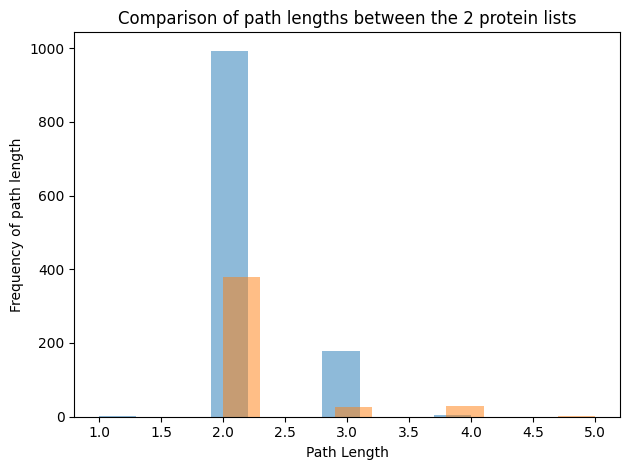

In [11]:
compare_path_lengths(list1_path_lengths, list2_path_lengths)